In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
import matplotlib.dates as mdates

def plot_congestion_poly(
    df: pd.DataFrame,
    *,
    date_col         = "date",
    t_start_col      = "発生時刻",
    t_peak_col       = "ピーク時刻",
    dur_col          = "渋滞時間",
    kp_start_col     = "発生Ｋｐ",
    peak_len_col     = "ピーク長",
    init_len_col     = "発生時渋滞長",
    facecolor        = "tab:blue",
    alpha            = 0.3,
    edgecolor        = "black",
    figsize          = (12, 6),
):
    """把 df 中每一行画成 KP-Time 三角形 / 截角三角形"""
    # === 1. 时间列合并成真正的 datetime =========================
    df = df.copy()
    df["t_start"] = pd.to_datetime(df[date_col] + " " + df[t_start_col])
    df["t_peak"]  = pd.to_datetime(df[date_col] + " " + df[t_peak_col])

    # 处理峰值时间跨日的情况：如果峰值 < 开始 ⇒ 认为跨到次日
    mask = df["t_peak"] < df["t_start"]
    df.loc[mask, "t_peak"] += pd.Timedelta(days=1)

    df["t_end"] = df["t_start"] + pd.to_timedelta(df[dur_col], unit="m")

    # === 2. 画图 ===============================================
    fig, ax = plt.subplots(figsize=figsize)
    kps, ts = [], []

    for _, row in df.iterrows():
        k0, k_peak = row[kp_start_col], row[kp_start_col] + row[peak_len_col]
        t0, t_peak, t_end = row["t_start"], row["t_peak"], row["t_end"]
        init_len = row[init_len_col]

        # 三角形 / 截角三角形顶点
        if init_len == 0:
            verts = [(k0, t0), (k_peak, t_peak), (k0, t_end)]
        else:
            k_init = k0 + init_len
            verts  = [(k0, t0), (k_init, t0), (k_peak, t_peak), (k0, t_end)]

        # matplotlib 需要把时间转成浮点数
        verts_mpl = [(x, mdates.date2num(y)) for x, y in verts]
        poly = Polygon(verts_mpl, closed=True,
                       facecolor=facecolor, alpha=alpha, edgecolor=edgecolor)
        ax.add_patch(poly)

        kps.extend([v[0] for v in verts])
        ts.extend([v[1] for v in verts])

    # === 3. 轴格式、美观设置 ====================================
    if kps and ts:
        ax.set_xlim(min(kps) - 1, max(kps) + 1)
        ax.set_ylim(min(ts) - pd.Timedelta(hours=1), max(ts) + pd.Timedelta(hours=1))

    ax.invert_yaxis()                                      # 早在上、晚在下
    ax.yaxis_date()
    ax.yaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    ax.set_xlabel("KP (km)")
    ax.set_ylabel("Time")
    ax.grid(True, ls="--", alpha=0.4)
    plt.tight_layout()
    return fig, ax

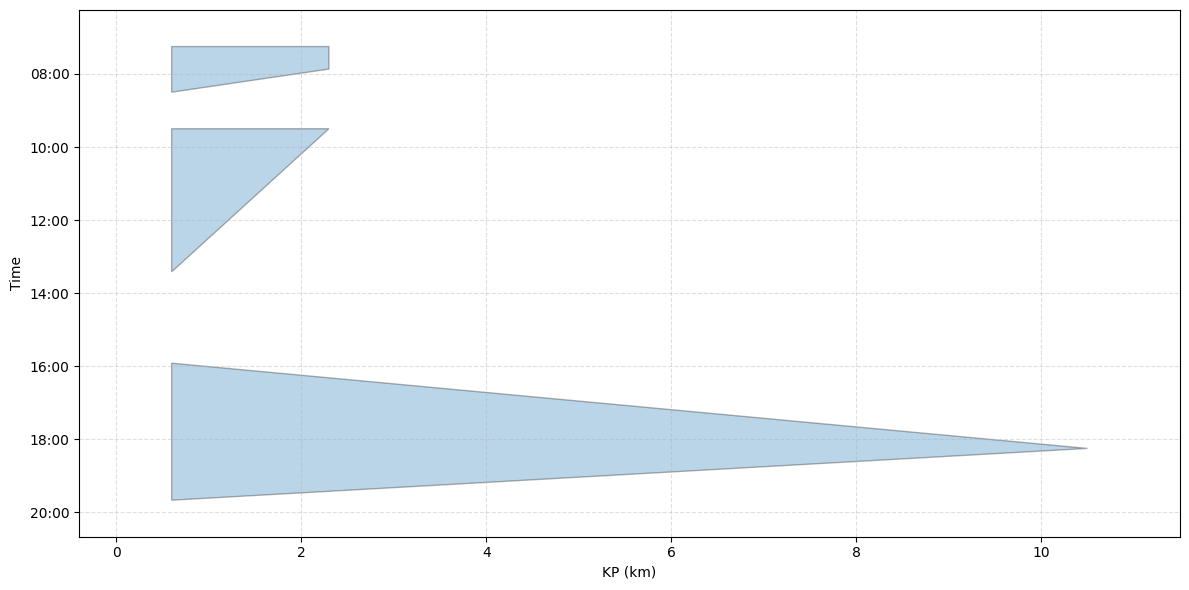

In [2]:
df = pd.read_csv("/home/dizhihuang/graduate/predict_workflow/data/processed_data/東北道_2021_03-19.csv")
fig, ax = plot_congestion_poly(df)
plt.show()